## Fun-a-thon 

27-maj-2026; DST - Copenhagen


In [ ]:
uv sync

Using CPython 3.13.13 interpreter at: /opt/python/bin/python
Creating virtual environment at: .venv
Resolved 187 packages in 1ms
   Updating https://github.com/InseeFrLab/torchTextClassifiers.git (HEAD)
   Updating https://github.com/InseeFrLab/torchTextClassifiers.git (HEAD)
   Updating https://github.com/InseeFrLab/torchTextClassifiers.git (HEAD)
⠙ Preparing packages... (0/180)
   Updating https://github.com/InseeFrLab/torchTextClassifiers.git (HEAD)   
⠙ Preparing packages... (0/180)
   Updating https://github.com/InseeFrLab/torchTextClassifiers.git (HEAD)   
⠙ Preparing packages... (0/180)
   Updating https://github.com/InseeFrLab/torchTextClassifiers.git (HEAD)   
⠙ Preparing packages... (0/180)
pydantic             ------------------------------     0 B/461.19 KiB
   Updating https://github.com/InseeFrLab/torchTextClassifiers.git (HEAD)   
⠙ Preparing packages... (0/180)
pydantic             ------------------------------     0 B/461.19 KiB
   Updating https://github.com/InseeFrL

<Axes: xlabel='code'>

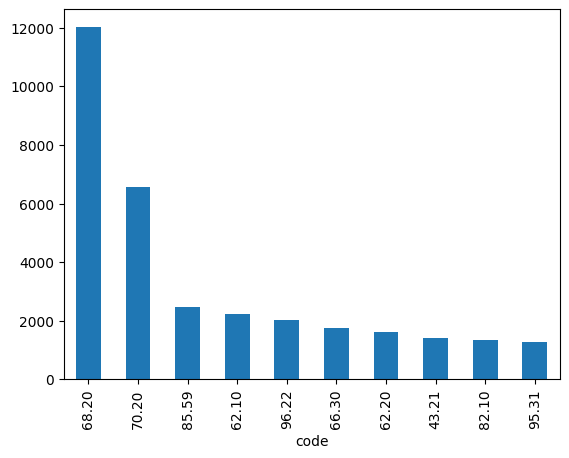

In [4]:
# %%
# If you need to change working directory (default is your interactive .py file location)
# import os
# os.chdir("<NEW_RELATIVE_LOCATION>")

import pandas as pd

df = pd.read_parquet(
    "https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet"
)
df.head()

# %%
df["code"].value_counts().head(10).plot(kind="bar")

# Load the data 
The dataset consists of synthetic labelled examples generated for the NACE rev 2.1 nomenclature. Each row contains a short text description (label) and the corresponding NACE code (code).

Exercice 1: Load the labelled dataset

#### 2.1 Question 1 — Import libraries and load environment variables
Import the package `mlflow` and the `load_dotenv` from the `dotenv` package. Then execute `load_dotenv(override=True)` to load your `.env` file.

In [ ]:
import mlflow
from dotenv import load_dotenv

load_dotenv(override=True)

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

#### 2.2 Question 2 — Load the dataset from s3
Use `Polars` to load the parquet file directly from this public URL:

https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet

Print the first rows and the total number of observations. Do you understand all columns?

In [ ]:
# importing Polars 
import polars as pl

# importing data
df = pl.read_parquet("https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet")

In [13]:
print(f"Printing the 1st rows of the dataset: {df.head()}")
print(f"\n")
print(f"total nr. of obs: {len(df)}")

Printing the 1st rows of the dataset: shape: (5, 3)
┌───────┬─────────────────────────────────┬─────────────────────────────────┐
│ code  ┆ name                            ┆ label                           │
│ ---   ┆ ---                             ┆ ---                             │
│ str   ┆ str                             ┆ str                             │
╞═══════╪═════════════════════════════════╪═════════════════════════════════╡
│ 01.11 ┆ Growing of cereals, other than… ┆ Pulses cultivation for market   │
│ 01.11 ┆ Growing of cereals, other than… ┆ Legume crop production activit… │
│ 01.11 ┆ Growing of cereals, other than… ┆ Broad bean farming operations   │
│ 01.11 ┆ Growing of cereals, other than… ┆ Chickpea harvesting and proces… │
│ 01.11 ┆ Growing of cereals, other than… ┆ Production of dried beans and … │
└───────┴─────────────────────────────────┴─────────────────────────────────┘


total nr. of obs: 70000


In [ ]:
# view dataset
df

#### 2.3 Question 3 — Count unique NACE codes
How many unique NACE codes are present in the dataset? Store this number in a variable called `n_classes`. This number will define the number of output classes the model must predict.

In [20]:
# variable n_classes
# datasetName['varName'].n_unique()
# n_unique()
n_classes = df['code'].n_unique()
print(f"nr. of unique NACE codes:", n_classes)

nr. of unique NACE codes: 311


#### 3.1 Question 1 — Split the dataset into train / validation / test sets
Use train_test_split from sklearn.model_selection to split the dataset into train, validation, and test sets (70% / 15% / 15%). Do not forget to choose a random_state. Separate the target y from the features X, and convert them to numpy arrays. You should obtain objects X_train, y_train, and so on.